# GDPR Enforcement Analysis (2018–2022)
## Identifying Compliance Risks through Data Analysis

## 1. Introduction
The General Data Protection Regulation (GDPR) imposes strict obligations on organizations processing personal data within the EU. 
This project analyzes GDPR enforcement data from 2018 to 2022 to identify patterns in regulatory penalties and assess compliance risks across different types of violations.

## 2. Data Source
The dataset is obtained from Kaggle and contains GDPR enforcement cases across European countries.
- Time period: 2018–2022  
- Number of cases: ~1500  
- Key variables: Country, Fine Amount, Violation Type, Legal Basis

## 3. Data Cleaning
The dataset was preprocessed to ensure consistency and usability for analysis.
Key steps include:
- Removing unnecessary columns
- Standardizing violation categories
- Handling missing values

In [9]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("valentindefour/gdpr-fines-referential")
files = os.listdir(path)
print(files)
file_path = os.path.join(path,files[0])
df = pd.read_csv(file_path)
df.head()

['export_GDPR_fines_cleaned.csv']


,Unnamed: 0,ID,Country,Date,Amount,Controller_Processor,Quoted_Art,Type,Art_,Art_10,...,Art_48,Art_5,Art_58,Art_6,Art_7,Art_8,Art_82,Art_88,Art_9,VIOLATED_ARTICLES
0,0,1542,ITALY,2022-11-10,20000,Sportitalia,5,Non-compliance with general data processing pr...,0,0,...,0,1,0,0,0,0,0,0,0,1
1,1,1541,ITALY,2022-11-24,1000000,Areti spa,"5,12,15,24",Non-compliance with general data processing pr...,0,0,...,0,1,0,0,0,0,0,0,0,4
2,2,1540,ROMANIA,2022-12-27,3000,Kaufland Romania SCS,"29,32",Insufficient technical and organisational meas...,0,0,...,0,0,0,0,0,0,0,0,0,2
3,3,1539,ROMANIA,2022-12-22,10000,SUDREZIDENȚIAL Broker S.R.L.,32,Insufficient technical and organisational meas...,0,0,...,0,0,0,0,0,0,0,0,0,1
4,4,1538,ITALY,2022-11-10,4000,Villafranca di Verona municipality,"5,6,2-",Non-compliance with general data processing pr...,0,0,...,0,1,0,1,0,0,0,0,0,3


## 4. Country-Level Analysis
We first examine which countries have the highest total GDPR fines.

In [2]:
top10 = df.groupby("Country")["Amount"].sum().sort_values(ascending=False).head(10)
top10

Country
IRELAND           913515900
LUXEMBOURG        746273600
FRANCE            293419300
ITALY             142201096
GERMANY            61547953
UNITED KINGDOM     60632800
SPAIN              57533790
GREECE             30464000
AUSTRIA            24775150
SWEDEN             16232230
Name: Amount, dtype: int64

In [3]:
top10 = df.groupby("Country")["Amount"].mean().sort_values(ascending = False).head(10)
top10

Country
IRELAND            5.075088e+07
LUXEMBOURG         3.244668e+07
FRANCE             8.891494e+06
UNITED KINGDOM     5.052733e+06
AUSTRIA            1.303955e+06
PORTUGAL           8.791429e+05
THE NETHERLANDS    7.352250e+05
ITALY              6.936639e+05
SWEDEN             6.011937e+05
GREECE             5.858462e+05
Name: Amount, dtype: float64

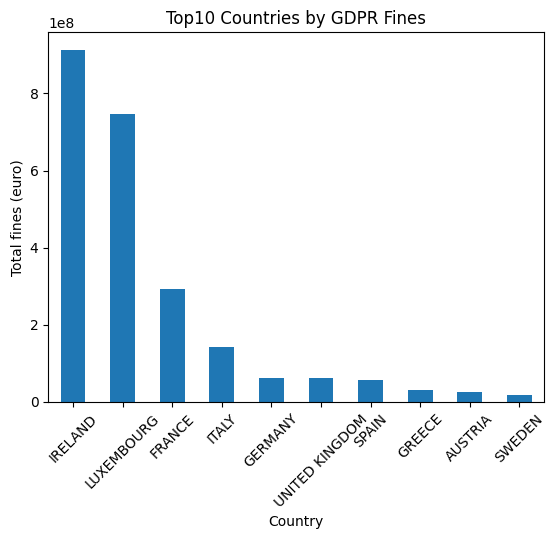

In [14]:
country_fines = df.groupby("Country")["Amount"].sum().sort_values(ascending = False)
top10 = country_fines.head(10)

import matplotlib.pyplot as plt
top10.plot(kind = "bar")
plt.title("Top10 Countries by GDPR Fines")
plt.ylabel("Total fines (euro)")
plt.xticks(rotation = 45)
plt.show()

### Key Findings
- GDPR fines are highly concentrated in a small number of countries, with Ireland and Luxembourg accounting for a disproportionate share.
- Ireland exhibits an exceptionally high total fine amount, far exceeding other EU countries.
- This may be due to Ireland hosting many multinational tech companies (e.g., Big Tech headquarters).
- Interestingly, larger economies such as Germany and Spain show relatively lower total fines compared to Ireland.
- The enforcement of GDPR appears uneven across countries.

### Interpretation
-  The dominance of Ireland in GDPR fines can be linked to the "one-stop-shop" mechanism, under which a single lead supervisory authority handles cross-border cases for multinational companies.

## 5. Violation Type Analysis
We analyze the frequency and severity of different types of GDPR violations.

In [5]:
df["Type"].value_counts()

Type
Insufficient legal basis for data processing                                         505
Non-compliance with general data processing principles                               360
Insufficient technical and organisational measures to ensure information security    285
Insufficient fulfilment of data subjects rights                                      138
Insufficient fulfilment of information obligations                                   125
Insufficient cooperation with supervisory authority                                   59
Insufficient fulfilment of data breach notification obligations                       25
Unknown                                                                               18
Insufficient data processing agreement                                                10
Insufficient involvement of data protection officer                                    7
Lack of appointment of data protection officer                                         7
Insuffcient fulf

In [6]:
df.groupby("Type")["Amount"].mean().sort_values(ascending = False)

Type
Non-compliance with general data processing principles                               3.503821e+06
Insufficient fulfilment of information obligations                                   1.896221e+06
Insufficient technical and organisational measures to ensure information security    1.305395e+06
Unknown                                                                              1.262750e+06
Insufficient legal basis for data processing                                         9.057289e+05
Insufficient fulfilment of data subjects rights                                      2.938701e+05
Insufficient data processing agreement                                               1.098610e+05
Insufficient involvement of data protection officer                                  9.380000e+04
Insufficient fulfilment of data breach notification obligations                      5.988644e+04
Lack of appointment of data protection officer                                       3.128571e+04
Insuffcient ful

### Key Findings
- Violations of fundamental GDPR principles (Art.5) result in the highest average fines, indicating systemic non-compliance rather than isolated incidents.
- Transparency-related violations (Art.13/14) and insufficient security measures (Art.32) are also associated with high penalties, highlighting regulatory focus on accountability and data protection safeguards.
- In contrast, violations related to legal basis (Art.6) occur more frequently but result in comparatively lower average fines, suggesting a distinction between common compliance failures and high-impact enforcement cases.

## 6. GDPR Risk Matrix
To better understand compliance risks, we combine frequency and average fines into a two-dimensional analysis.

In [13]:
counts = df["Type"].value_counts()
means = df.groupby("Type")["Amount"].mean()

result = pd.concat([counts,means], axis = 1)
result.columns = ["Count","Mean_Fine"]
result.sort_values(by="Mean_Fine", ascending=False)

,Count,Mean_Fine
Type,,
Non-compliance with general data processing principles,360,3.503821e+06
Insufficient fulfilment of information obligations,125,1.896221e+06
Insufficient technical and organisational measures to ensure information security,285,1.305395e+06
Unknown,18,1.262750e+06
Insufficient legal basis for data processing,505,9.057289e+05
Insufficient fulfilment of data subjects rights,138,2.938701e+05
Insufficient data processing agreement,10,1.098610e+05
Insufficient involvement of data protection officer,7,9.380000e+04
Insufficient fulfilment of data breach notification obligations,25,5.988644e+04


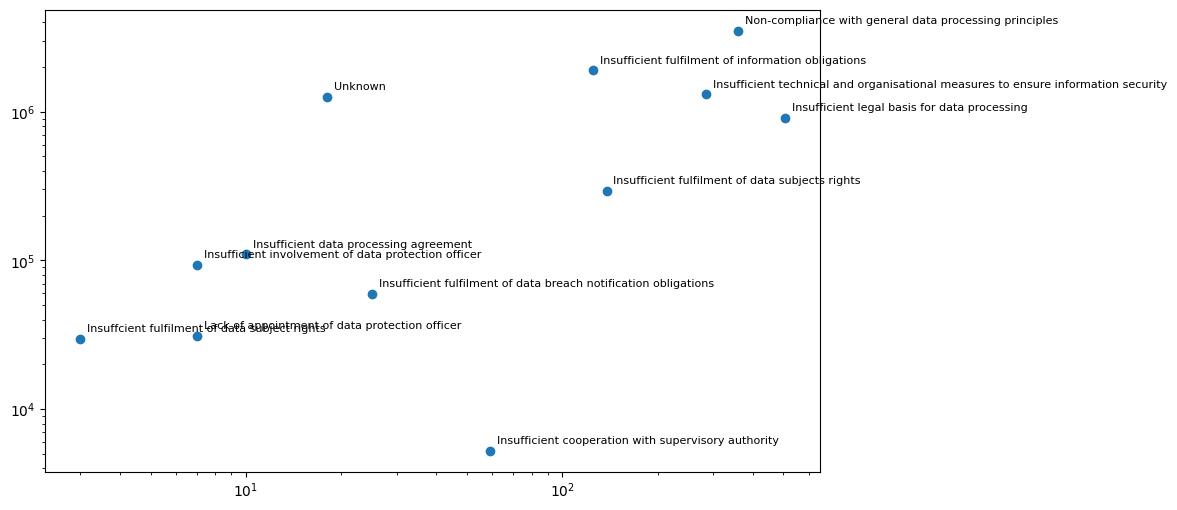

In [21]:
result = pd.concat([counts, means], axis=1)
result.columns = ["Count", "Mean_Fine"]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(result["Count"], result["Mean_Fine"])
plt.xscale("log")
plt.yscale("log")
for i, txt in enumerate(result.index):
    x = result["Count"].iloc[i]
    y = result["Mean_Fine"].iloc[i]

    plt.annotate(
        txt,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.show()

### Risk Interpretation

The risk matrix reveals distinct categories of GDPR violations:

- **High-risk violations (high frequency & high fines):**  
  Violations of general data processing principles (Art.5) and security-related obligations (Art.32) fall into this category, representing the most critical compliance risks.
  
- **High-impact but less frequent violations:**  
  Transparency-related violations (Art.13/14) appear less frequently but result in substantial penalties, indicating strict regulatory enforcement.

- **Frequent but lower-impact violations:**  
  Violations related to legal basis (Art.6) are common but generally associated with lower average fines.
This distinction highlights that not all frequent violations carry the same level of regulatory risk.

## 7. Time-Trend Analysist

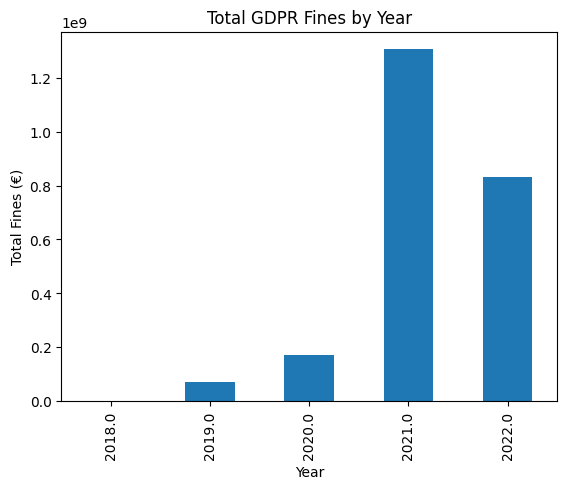

In [11]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year

yearly_fines = df.groupby("Year")["Amount"].sum()

yearly_fines.plot(kind="bar")
plt.title("Total GDPR Fines by Year")
plt.ylabel("Total Fines (€)")
plt.show()

### Time Trend Insight

The total amount of GDPR fines shows significant variation across years, with a sharp increase in later periods.

However, this trend should be interpreted with caution. The dataset covers a relatively short time span, and the observed peaks are likely influenced by a small number of large enforcement cases rather than a steady increase in regulatory intensity.

Therefore, while there are indications of growing enforcement activity, the data does not allow for a definitive conclusion regarding long-term trends.

## 8. Final Conclusion

This project provides a data-driven analysis of GDPR enforcement patterns between 2018 and 2022.

The findings reveal that GDPR enforcement is not evenly distributed across countries or violation types. A small number of countries, particularly Ireland and Luxembourg, account for a disproportionately large share of total fines, largely due to the concentration of multinational technology companies.

At the violation level, the analysis shows a clear distinction between frequent and high-impact violations. While violations related to the legal basis for processing (Art.6) occur most frequently, the highest fines are associated with breaches of fundamental principles (Art.5), transparency obligations (Art.13/14), and security requirements (Art.32).

The risk matrix further highlights this distinction by identifying categories of violations that combine high frequency with high financial penalties, representing the most critical compliance risks.

Finally, while the time trend suggests increasing enforcement activity, the limited time span and the influence of large individual cases make it difficult to draw definitive conclusions about long-term regulatory developments.

Overall, the results demonstrate that GDPR enforcement is shaped by both structural factors (such as the location of data controllers) and the severity of legal violations, emphasizing the importance of both legal compliance and organizational data governance.